# Palestine Tourism Recommendation System
## Content-Based Filtering using Cosine Similarity

**Project:** AI Travel Squad — AI Track Contribution  
**Approach:** Content-Based Filtering  
**Algorithm:** Cosine Similarity (via Scikit-learn)  
**Dataset:** `palestine_tourist_attractions_v2.csv` — 331 tourist places across Palestinian cities

---

### How It Works

The user enters their preferences (city, budget, trip type, age group, number of people).  
I convert both the user preferences and each place's features into vectors, then measure how similar the user's vector is to each place's vector using **cosine similarity**.  
The places with the highest similarity scores are returned as recommendations.

```
User Input  →  Feature Vector  →  Cosine Similarity  →  Top 5-10 Recommendations
```

## 1. Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


## 2. Load and Explore the Dataset

In [25]:
df = pd.read_csv('Data\palestine_tourist_attractions_v2.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (331, 13)
Columns: ['ID', 'Place_Name', 'type', 'City', 'Budget_Level', 'Age_Group', 'Trip_Type', 'Description', 'Latitude', 'Longitude', 'Coordinate_Source', 'Geocode_Status', 'Estimated_Cost_ILS']


,ID,Place_Name,type,City,Budget_Level,Age_Group,Trip_Type,Description,Latitude,Longitude,Coordinate_Source,Geocode_Status,Estimated_Cost_ILS
0,1,Mosque of 'Umar Ibn al-Khattab (Qalqilya),Religious,Qalqilya,Medium,All,Religious,The Mosque of Umar Ibn al-Khattab (Qalqilya) i...,32.190557,34.966009,OpenStreetMap Photon (city centroid fallback),City-level,55
1,2,Al-Far'a Tower,Historic Old City,Tubas,Medium,All,Cultural,Al-Far'a Tower is a historic watchtower struct...,32.323439,35.369366,OpenStreetMap Photon (city centroid fallback),City-level,60
2,3,Khirbet Keshda (Ruin),Archaeological,Tubas,Low,Youth,Adventure,Khirbet Keshda is an archaeological ruin site ...,32.323439,35.369366,OpenStreetMap Photon (city centroid fallback),City-level,10
3,4,Khirbet Aniun (Ruin),Archaeological,Tubas,Low,Youth,Adventure,Khirbet Aniun is an archaeological ruin site i...,32.323439,35.369366,OpenStreetMap Photon (city centroid fallback),City-level,15
4,5,Khirbat Um Kubiesh ('Atuf),Archaeological,Tubas,Low,Youth,Adventure,"Khirbat Um Kubiesh, near 'Atuf in the Tubas go...",32.323439,35.369366,OpenStreetMap Photon (city centroid fallback),City-level,5


In [26]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())

print()
print('Data types:')
print(df.dtypes)

Missing values:
ID                    0
Place_Name            0
type                  0
City                  0
Budget_Level          0
Age_Group             0
Trip_Type             0
Description           0
Latitude              0
Longitude             0
Coordinate_Source     0
Geocode_Status        0
Estimated_Cost_ILS    0
dtype: int64

Data types:
ID                      int64
Place_Name                str
type                      str
City                      str
Budget_Level              str
Age_Group                 str
Trip_Type                 str
Description               str
Latitude              float64
Longitude             float64
Coordinate_Source         str
Geocode_Status            str
Estimated_Cost_ILS      int64
dtype: object


In [27]:
# Unique values in each categorical feature
categorical_cols = ['type', 'City', 'Budget_Level', 'Age_Group', 'Trip_Type']

for col in categorical_cols:
    print(f'{col}: {df[col].unique().tolist()}')

type: ['Religious', 'Historic Old City', 'Archaeological', 'Museum', 'Family/Recreational', 'Nature & Trails', 'Education', 'Historic', 'Cultural']
City: ['Qalqilya', 'Tubas', 'Jenin', 'Tulkarm', 'Nablus', 'Jerusalem', 'Bethlehem', 'Jericho', 'Hebron', 'Ramallah']
Budget_Level: ['Medium', 'Low', 'High']
Age_Group: ['All', 'Youth', 'Family']
Trip_Type: ['Religious', 'Cultural', 'Adventure', 'Family', 'Relaxing', 'Educational']


### 2.1 Quick Visual Overview

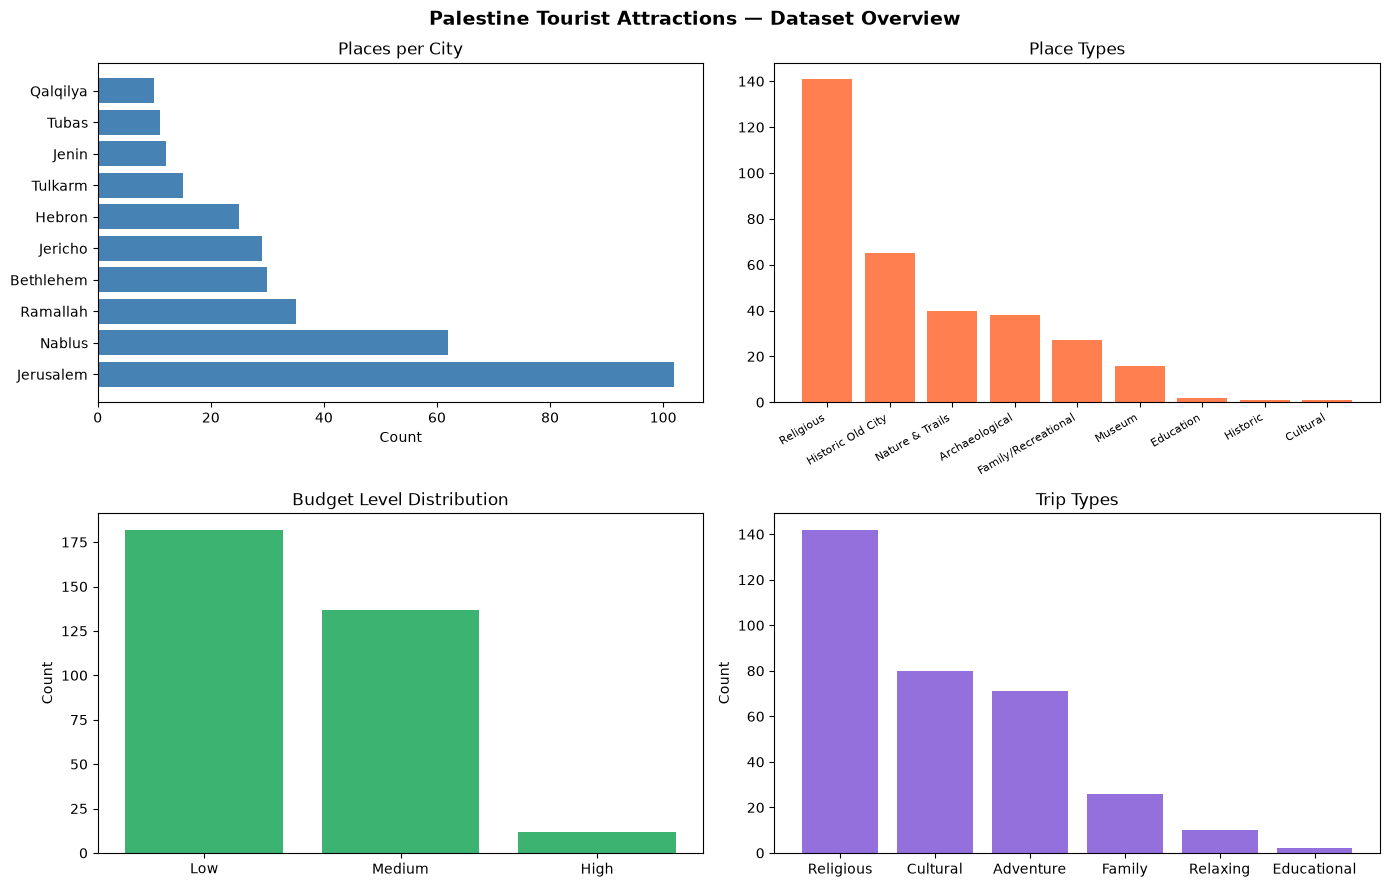

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Palestine Tourist Attractions — Dataset Overview', fontsize=14, fontweight='bold')

# Places per city
city_counts = df['City'].value_counts()
axes[0, 0].barh(city_counts.index, city_counts.values, color='steelblue')
axes[0, 0].set_title('Places per City')
axes[0, 0].set_xlabel('Count')

# Place types
type_counts = df['type'].value_counts()
axes[0, 1].bar(range(len(type_counts)), type_counts.values, color='coral')
axes[0, 1].set_xticks(range(len(type_counts)))
axes[0, 1].set_xticklabels(type_counts.index, rotation=30, ha='right', fontsize=8)
axes[0, 1].set_title('Place Types')

# Budget levels
budget_counts = df['Budget_Level'].value_counts()
axes[1, 0].bar(budget_counts.index, budget_counts.values, color='mediumseagreen')
axes[1, 0].set_title('Budget Level Distribution')
axes[1, 0].set_ylabel('Count')

# Trip types
trip_counts = df['Trip_Type'].value_counts()
axes[1, 1].bar(trip_counts.index, trip_counts.values, color='mediumpurple')
axes[1, 1].set_title('Trip Types')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Engineering

I need to convert the categorical columns into a numeric format that the cosine similarity function can work with.

**Method: One-Hot Encoding**  
Each category becomes its own binary column (0 or 1). For example, `City = Nablus` becomes `City_Nablus = 1` and all other city columns = 0.

**Columns used:**
| Column | Role |
|--------|------|
| `type` | What kind of place it is |
| `City` | Which city it's in |
| `Budget_Level` | Cost range |
| `Age_Group` | Who it suits |
| `Trip_Type` | What kind of experience |

In [29]:
feature_cols = ['type', 'City', 'Budget_Level', 'Age_Group', 'Trip_Type']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
feature_matrix = encoder.fit_transform(df[feature_cols])

print(f'Feature matrix shape: {feature_matrix.shape}')
print(f'  → {df.shape[0]} places × {feature_matrix.shape[1]} features')
print()
print('Features after encoding:')
for name in encoder.get_feature_names_out(feature_cols):
    print(f'  {name}')

Feature matrix shape: (331, 31)
  → 331 places × 31 features

Features after encoding:
  type_Archaeological
  type_Cultural
  type_Education
  type_Family/Recreational
  type_Historic
  type_Historic Old City
  type_Museum
  type_Nature & Trails
  type_Religious
  City_Bethlehem
  City_Hebron
  City_Jenin
  City_Jericho
  City_Jerusalem
  City_Nablus
  City_Qalqilya
  City_Ramallah
  City_Tubas
  City_Tulkarm
  Budget_Level_High
  Budget_Level_Low
  Budget_Level_Medium
  Age_Group_All
  Age_Group_Family
  Age_Group_Youth
  Trip_Type_Adventure
  Trip_Type_Cultural
  Trip_Type_Educational
  Trip_Type_Family
  Trip_Type_Relaxing
  Trip_Type_Religious


### What Does the Feature Matrix Look Like?

Each row is a place, each column is a one-hot encoded feature.  
A `1` means the place has that feature, `0` means it doesn't.

In [30]:
# Show first 5 rows as a readable DataFrame
feature_df = pd.DataFrame(
    feature_matrix[:5],
    columns=encoder.get_feature_names_out(feature_cols),
    index=df['Place_Name'][:5]
)

# Only show columns with at least one 1 in first 5 rows
feature_df = feature_df.loc[:, (feature_df == 1).any()]
feature_df

,type_Archaeological,type_Historic Old City,type_Religious,City_Qalqilya,City_Tubas,Budget_Level_Low,Budget_Level_Medium,Age_Group_All,Age_Group_Youth,Trip_Type_Adventure,Trip_Type_Cultural,Trip_Type_Religious
Place_Name,,,,,,,,,,,,
Mosque of 'Umar Ibn al-Khattab (Qalqilya),0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
Al-Far'a Tower,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
Khirbet Keshda (Ruin),1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
Khirbet Aniun (Ruin),1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
Khirbat Um Kubiesh ('Atuf),1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


## 4. Building the Recommendation Model

### How Cosine Similarity Works

Cosine similarity measures the angle between two vectors. If two vectors point in the same direction (same features), the angle is 0° and cosine = **1.0** (perfect match). If they point in completely different directions, cosine = **0.0** (no match).

```
similarity = (A · B) / (||A|| × ||B||)
```

- Result of **1.0** → the place matches the user's preferences perfectly  
- Result of **0.0** → the place has nothing in common with what the user wants

### Trip Type → Place Type Mapping

The dataset uses `type` (place category) and `Trip_Type` (experience category) as separate columns. I map each trip type to the most relevant place type so the user doesn't have to choose both manually.

In [31]:
TRIP_TYPE_TO_PLACE_TYPE = {
    'Religious':   'Religious',
    'Cultural':    'Historic Old City',
    'Adventure':   'Nature & Trails',
    'Family':      'Family/Recreational',
    'Relaxing':    'Nature & Trails',
    'Educational': 'Museum'
}

print('Trip Type → Inferred Place Type mapping:')
for trip, place in TRIP_TYPE_TO_PLACE_TYPE.items():
    print(f'  {trip:15} → {place}')

Trip Type → Inferred Place Type mapping:
  Religious       → Religious
  Cultural        → Historic Old City
  Adventure       → Nature & Trails
  Family          → Family/Recreational
  Relaxing        → Nature & Trails
  Educational     → Museum


Now I put everything together in one function that takes the user's preferences,
builds their vector, computes similarity against all 331 places, and returns
the top N matches ranked by score.

In [32]:
def get_recommendations(city, budget_level, trip_type, age_group,
                        num_people=1, top_n=10, verbose=True):
    """
    Recommend tourist places in Palestine based on user preferences.

    Parameters
    ----------
    city         : str   - Target city. Options: Nablus, Jerusalem, Bethlehem,
                           Ramallah, Jericho, Hebron, Jenin, Tulkarm, Tubas, Qalqilya
    budget_level : str   - 'Low', 'Medium', or 'High'
    trip_type    : str   - 'Religious', 'Cultural', 'Adventure',
                           'Family', 'Relaxing', 'Educational'
    age_group    : str   - 'Youth', 'Family', or 'All'
    num_people   : int   - Number of people (used to estimate total trip cost)
    top_n        : int   - Number of recommendations to return (default: 10)
    verbose      : bool  - Print a summary header

    Returns
    -------
    pandas.DataFrame with columns:
        Place_Name, type, City, Budget_Level, Age_Group, Trip_Type,
        Description, Estimated_Cost_ILS, Total_Cost_ILS, Similarity_Score
    """

    # Infer place type from trip type
    place_type = TRIP_TYPE_TO_PLACE_TYPE.get(trip_type, 'Historic Old City')

    # Build user preference vector (same shape as each place's feature vector)
    user_input = {
        'type':         place_type,
        'City':         city,
        'Budget_Level': budget_level,
        'Age_Group':    age_group,
        'Trip_Type':    trip_type
    }

    user_df     = pd.DataFrame([user_input])
    user_vector = encoder.transform(user_df)

    # Compute cosine similarity between user vector and ALL places
    similarities = cosine_similarity(user_vector, feature_matrix)[0]

    # Attach scores to the dataset
    result_df = df.copy()
    result_df['Similarity_Score'] = np.round(similarities, 4)
    result_df['Total_Cost_ILS']   = result_df['Estimated_Cost_ILS'] * num_people

    # Pick the top N highest-scoring places
    recommendations = (
        result_df
        .nlargest(top_n, 'Similarity_Score')
        [['Place_Name', 'type', 'City', 'Budget_Level', 'Age_Group',
          'Trip_Type', 'Description', 'Estimated_Cost_ILS',
          'Total_Cost_ILS', 'Similarity_Score']]
        .reset_index(drop=True)
    )
    recommendations.index += 1

    if verbose:
        print(f"User Preferences  →  City: {city} | Budget: {budget_level} "
              f"| Trip: {trip_type} | Age: {age_group} | People: {num_people}")
        print(f"Inferred place type: {place_type}")
        print(f"Top {top_n} recommendations out of {len(df)} places:")
        print('-' * 70)

    return recommendations

print('Recommendation function defined.')

Recommendation function defined.


## 5. Testing the Model

I test with three different user profiles to confirm the model returns sensible, varied results.

### Test 1 — Adventure seeker in Nablus (Youth, Low budget)

In [33]:
r1 = get_recommendations(
    city='Nablus',
    budget_level='Low',
    trip_type='Adventure',
    age_group='Youth',
    num_people=3,
    top_n=8
)

r1[['Place_Name', 'type', 'City', 'Estimated_Cost_ILS', 'Total_Cost_ILS', 'Similarity_Score']]

User Preferences  →  City: Nablus | Budget: Low | Trip: Adventure | Age: Youth | People: 3
Inferred place type: Nature & Trails
Top 8 recommendations out of 331 places:
----------------------------------------------------------------------


,Place_Name,type,City,Estimated_Cost_ILS,Total_Cost_ILS,Similarity_Score
1,Ein Qarioun (Spring),Nature & Trails,Nablus,10,30,1.0
2,Mount Gerizim and the Samaritan Sect.,Nature & Trails,Nablus,5,15,1.0
3,Wadi Al-Tuffah (Apple Valley) and the Water Mills,Nature & Trails,Nablus,20,60,1.0
4,Bal'a Forests,Nature & Trails,Tulkarm,0,0,0.8
5,Roman Colonnaded Street,Archaeological,Nablus,5,15,0.8
6,"Shechem - The Canaanite City, Tel - Balata",Archaeological,Nablus,20,60,0.8
7,The Roman Colonnaded Street,Archaeological,Nablus,0,0,0.8
8,Tel Sufar - Sufan,Archaeological,Nablus,5,15,0.8


### Test 2 — Religious trip to Jerusalem (Medium budget, for all ages)

In [34]:
r2 = get_recommendations(
    city='Jerusalem',
    budget_level='Medium',
    trip_type='Religious',
    age_group='All',
    num_people=2,
    top_n=8
)

r2[['Place_Name', 'type', 'City', 'Estimated_Cost_ILS', 'Total_Cost_ILS', 'Similarity_Score']]

User Preferences  →  City: Jerusalem | Budget: Medium | Trip: Religious | Age: All | People: 2
Inferred place type: Religious
Top 8 recommendations out of 331 places:
----------------------------------------------------------------------


,Place_Name,type,City,Estimated_Cost_ILS,Total_Cost_ILS,Similarity_Score
1,Rassassi Mosque and Al Mawardyah School,Religious,Jerusalem,20,40,1.0
2,Al Mujahid Badreddin Lulu Mosque,Religious,Jerusalem,55,110,1.0
3,Red Minaret mosque,Religious,Jerusalem,30,60,1.0
4,Salman Alfarissi Mosque,Religious,Jerusalem,20,40,1.0
5,Nabi Samuel. Ghneim mosque,Religious,Jerusalem,20,40,1.0
6,Mosque of Omar,Religious,Jerusalem,50,100,1.0
7,Al Jannat Mosque,Religious,Jerusalem,40,80,1.0
8,Al Aqsa Mosque,Religious,Jerusalem,50,100,1.0


### Test 3 — Family cultural outing in Bethlehem (Medium budget)

In [35]:
r3 = get_recommendations(
    city='Bethlehem',
    budget_level='Medium',
    trip_type='Cultural',
    age_group='Family',
    num_people=4,
    top_n=8
)

r3[['Place_Name', 'type', 'City', 'Estimated_Cost_ILS', 'Total_Cost_ILS', 'Similarity_Score']]

User Preferences  →  City: Bethlehem | Budget: Medium | Trip: Cultural | Age: Family | People: 4
Inferred place type: Historic Old City
Top 8 recommendations out of 331 places:
----------------------------------------------------------------------


,Place_Name,type,City,Estimated_Cost_ILS,Total_Cost_ILS,Similarity_Score
1,Al-Kayed Palace,Historic Old City,Nablus,55,220,0.8
2,Abd Al-Hadi Palace,Historic Old City,Nablus,25,100,0.8
3,Al-Nimr Palace,Historic Old City,Nablus,25,100,0.8
4,Touqan Palace,Historic Old City,Nablus,45,180,0.8
5,Sittunshu Palace,Historic Old City,Jerusalem,40,160,0.8
6,Bethlehem Museum,Museum,Bethlehem,55,220,0.8
7,Palestinian Heritage Center,Museum,Bethlehem,50,200,0.8
8,Al-Far'a Tower,Historic Old City,Tubas,60,240,0.6


**evaluate_recommendations**

In [36]:
def evaluate_recommendations(city, budget_level, trip_type, age_group, num_people=1, top_n=10):
    """
    Returns recommendations with an extra column showing how many
    of the user's preferences each place matches (out of 5).
    """
    place_type = TRIP_TYPE_TO_PLACE_TYPE.get(trip_type, 'Historic Old City')

    results = get_recommendations(
        city=city,
        budget_level=budget_level,
        trip_type=trip_type,
        age_group=age_group,
        num_people=num_people,
        top_n=top_n,
        verbose=False
    ).copy()

    results['Matching_Features'] = (
        (results['City']         == city).astype(int) +
        (results['type']         == place_type).astype(int) +
        (results['Budget_Level'] == budget_level).astype(int) +
        (results['Age_Group']    == age_group).astype(int) +
        (results['Trip_Type']    == trip_type).astype(int)
    )

    return results
eval_results = evaluate_recommendations(
    city='Nablus',
    budget_level='Low',
    trip_type='Adventure',
    age_group='Youth',
    top_n=10
)

eval_results[['Place_Name', 'City', 'type', 'Similarity_Score', 'Matching_Features']]

,Place_Name,City,type,Similarity_Score,Matching_Features
1,Ein Qarioun (Spring),Nablus,Nature & Trails,1.0,5
2,Mount Gerizim and the Samaritan Sect.,Nablus,Nature & Trails,1.0,5
3,Wadi Al-Tuffah (Apple Valley) and the Water Mills,Nablus,Nature & Trails,1.0,5
4,Bal'a Forests,Tulkarm,Nature & Trails,0.8,4
5,Roman Colonnaded Street,Nablus,Archaeological,0.8,4
6,"Shechem - The Canaanite City, Tel - Balata",Nablus,Archaeological,0.8,4
7,The Roman Colonnaded Street,Nablus,Archaeological,0.8,4
8,Tel Sufar - Sufan,Nablus,Archaeological,0.8,4
9,Sama Nablus Park,Nablus,Nature & Trails,0.8,4
10,Mount Zion Cemetery (Catholic),Jerusalem,Nature & Trails,0.8,4


## 6. Similarity Score Distribution

Here I visualize how similarity scores are spread across all 331 places for a sample user profile. This helps us understand whether the model differentiates well between matching and non-matching places.

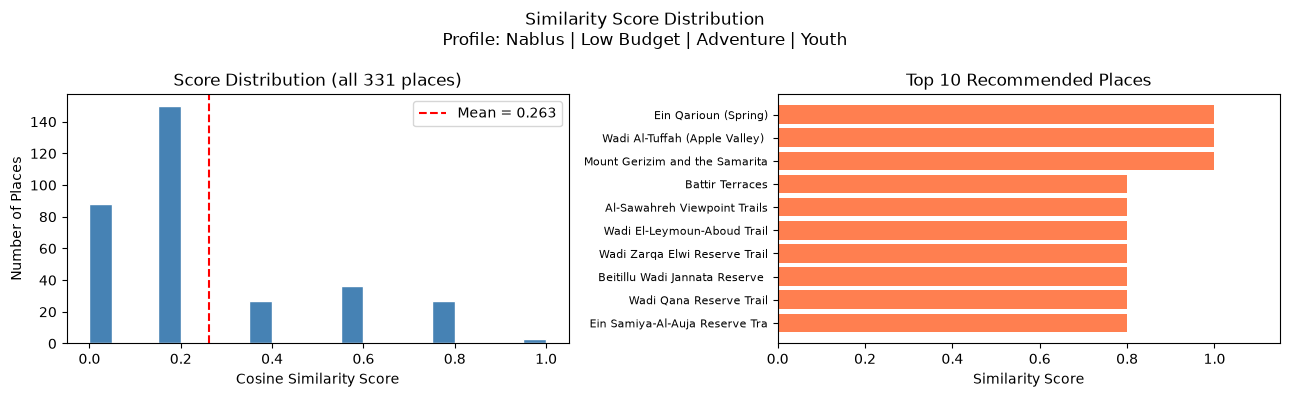

In [37]:
# Compute similarity scores for Test 1 profile (across all places)
sample_user = {
    'type': 'Nature & Trails',
    'City': 'Nablus',
    'Budget_Level': 'Low',
    'Age_Group': 'Youth',
    'Trip_Type': 'Adventure'
}

user_vector = encoder.transform(pd.DataFrame([sample_user]))
scores = cosine_similarity(user_vector, feature_matrix)[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    'Similarity Score Distribution\n'
    'Profile: Nablus | Low Budget | Adventure | Youth',
    fontsize=12
)

# Histogram
axes[0].hist(scores, bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Cosine Similarity Score')
axes[0].set_ylabel('Number of Places')
axes[0].set_title('Score Distribution (all 331 places)')
axes[0].axvline(np.mean(scores), color='red', linestyle='--',
                label=f'Mean = {np.mean(scores):.3f}')
axes[0].legend()

# Top 10 scores
top_idx  = np.argsort(scores)[::-1][:10]
top_names = df['Place_Name'].iloc[top_idx].str[:30]
top_scores = scores[top_idx]

axes[1].barh(range(10), top_scores[::-1], color='coral')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(top_names[::-1].values, fontsize=8)
axes[1].set_xlabel('Similarity Score')
axes[1].set_title('Top 10 Recommended Places')
axes[1].set_xlim(0, 1.15)

plt.tight_layout()
plt.savefig('similarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Export the Model for Backend Integration

The backend team can load these two files and call `cosine_similarity()` directly — no need to re-fit the encoder.

In [38]:
# Save the encoder (fitted on training data)
joblib.dump(encoder, 'tourism_encoder.pkl')

# Save the pre-computed feature matrix (all 331 places already encoded)
np.save('feature_matrix.npy', feature_matrix)

print('Exported:')
print('  tourism_encoder.pkl   → OneHotEncoder fitted on all 331 places')
print('  feature_matrix.npy   → Pre-computed feature matrix (331 × 31)')
print()
print('Usage in backend (Python):')
print("  encoder        = joblib.load('tourism_encoder.pkl')")
print("  feature_matrix = np.load('feature_matrix.npy')")
print("  # Then call get_recommendations(...)")

Exported:
  tourism_encoder.pkl   → OneHotEncoder fitted on all 331 places
  feature_matrix.npy   → Pre-computed feature matrix (331 × 31)

Usage in backend (Python):
  encoder        = joblib.load('tourism_encoder.pkl')
  feature_matrix = np.load('feature_matrix.npy')
  # Then call get_recommendations(...)


In [39]:
# Verify: reload encoder and reproduce Test 1 results
encoder_loaded = joblib.load('tourism_encoder.pkl')
matrix_loaded  = np.load('feature_matrix.npy')

sample_user = pd.DataFrame([{
    'type': 'Nature & Trails',
    'City': 'Nablus',
    'Budget_Level': 'Low',
    'Age_Group': 'Youth',
    'Trip_Type': 'Adventure'
}])

v = encoder_loaded.transform(sample_user)
s = cosine_similarity(v, matrix_loaded)[0]

top5 = df.copy()
top5['score'] = s
top5 = top5.nlargest(5, 'score')[['Place_Name', 'City', 'score']]
top5.index = range(1, 6)

print('Verification — same results after reload:')
print(top5.to_string())

Verification — same results after reload:
                                          Place_Name     City  score
1                               Ein Qarioun (Spring)   Nablus    1.0
2              Mount Gerizim and the Samaritan Sect.   Nablus    1.0
3  Wadi Al-Tuffah (Apple Valley) and the Water Mills   Nablus    1.0
4                                      Bal'a Forests  Tulkarm    0.8
5                            Roman Colonnaded Street   Nablus    0.8


## 8. Summary

### What I Built
A content-based recommendation system for Palestinian tourism using **Cosine Similarity**.

### Technical Details
| Item | Value |
|------|-------|
| Algorithm | Cosine Similarity |
| Encoding | One-Hot Encoding (OneHotEncoder) |
| Feature matrix size | 331 places × 31 features |
| Features used | type, City, Budget_Level, Age_Group, Trip_Type |
| User inputs | City, Budget, Trip Type, Age Group, # of people |
| Output | Top 5–10 places ranked by similarity score |

### How the Score Is Interpreted
- **1.0** → The place matches every user preference exactly  
- **0.6–0.8** → The place is a good partial match  
- **0.0** → The place shares nothing with the user's preferences  

### Files Exported for Backend
- `tourism_encoder.pkl` → fitted OneHotEncoder  
- `feature_matrix.npy` → pre-computed 331 × 31 matrix  
- `palestine_tourist_attractions_v2.csv` → original dataset  

### Limitations & Future Improvements
- The dataset has 331 places; more data would improve recommendation diversity  
- Adding **TF-IDF on `Description`** would capture richer semantic meaning  
- User feedback (ratings) could enable **collaborative filtering** in the future